# IMPORTS

In [150]:
import os
import heapq                      # pending list: always pop the point with the latest t
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

import stable_baselines3, sb3_contrib
print('numpy', np.__version__, '| gymnasium', gym.__version__,
      '| sb3', stable_baselines3.__version__, '| sb3_contrib', sb3_contrib.__version__)

numpy 2.5.0 | gymnasium 1.3.0 | sb3 2.9.0 | sb3_contrib 2.9.0


# True solution

grid:  nx = 100,  nt = 1090,  dx = 0.0101,  dt = 0.0004591
diffusion number  alpha*dt/dx^2 = 0.450
Courant number    c*dt/dx       = 0.045

check 1  max |u(x,0) - u0(x)|  = 5.65e-07
check 2  |u(0,t)|, |u(1,t)|     = 0.00e+00, 4.76e-17
check 3  PDE residual at (0.5, 75dt) = 2.94e-07   (|u_t| = 1.03e+00)


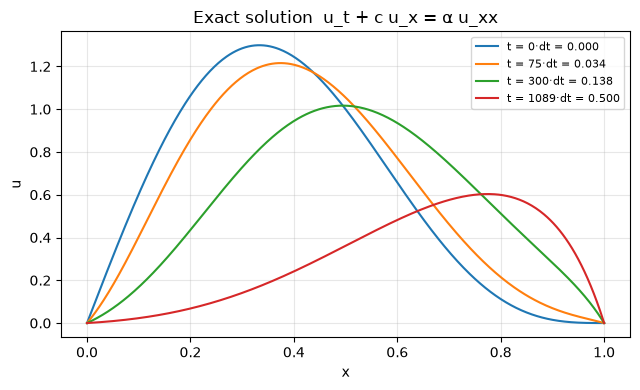

In [151]:
# ── PDE:  u_t + c u_x = alpha u_xx   on x in [0, 1],  u(0,t) = u(1,t) = 0 ──
alpha = 0.1          # diffusion coefficient
c     = 1.0          # advection speed

# ── Grid: every point the map can use sits on this grid ──
nx = 100
T  = 0.5
dx = 1.0 / (nx - 1)
dt_cfl = min(0.9 * dx / c, 0.45 * dx**2 / alpha)     # advective and diffusive limits
nt = max(int(np.ceil(T / dt_cfl)) + 1, 10)
dt = T / (nt - 1)

print(f"grid:  nx = {nx},  nt = {nt},  dx = {dx:.4g},  dt = {dt:.4g}")
print(f"diffusion number  alpha*dt/dx^2 = {alpha * dt / dx**2:.3f}")
print(f"Courant number    c*dt/dx       = {c * dt / dx:.3f}")

# ── Exact solution ──
# u = exp(b x - alpha b^2 t) v  with  b = c / (2 alpha)  removes the advection term;
# v solves the heat equation, so it is a sine series.
_xq = np.linspace(0.0, 1.0, 80001)
_b  = c / (2 * alpha)
u0  = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)
_v0 = u0(_xq) * np.exp(-_b * _xq)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(_v0 * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    """Exact u at positions x (scalar or array) and one time t. Always returns an array."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(axis=1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

# ── Checks ──
xs = np.linspace(0, 1, 501)
tq = 75 * dt
print(f"\ncheck 1  max |u(x,0) - u0(x)|  = {np.abs(u_true(xs, 0.0) - u0(xs)).max():.2e}")
print(f"check 2  |u(0,t)|, |u(1,t)|     = {abs(u_true(0.0, tq)[0]):.2e}, {abs(u_true(1.0, tq)[0]):.2e}")
xc, e = 0.5, 1e-4
u_t  = (u_true(xc, tq + e) - u_true(xc, tq - e))[0] / (2 * e)
u_x  = (u_true(xc + e, tq) - u_true(xc - e, tq))[0] / (2 * e)
u_xx = (u_true(xc + e, tq) - 2 * u_true(xc, tq) + u_true(xc - e, tq))[0] / e**2
print(f"check 3  PDE residual at (0.5, 75dt) = {abs(u_t + c * u_x - alpha * u_xx):.2e}   (|u_t| = {abs(u_t):.2e})")

# ── Picture: the solution at a few times ──
fig, ax = plt.subplots(figsize=(6.5, 4))
for n_lvl in [0, 75, 300, nt - 1]:
    ax.plot(xs, u_true(xs, n_lvl * dt), label=f"t = {n_lvl}·dt = {n_lvl * dt:.3f}")
ax.set(xlabel="x", ylabel="u", title="Exact solution  u_t + c u_x = α u_xx")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# FD Soltuion

FD weights = [0.472727 0.1      0.427273],  sum = 1.000000,  all positive: True

  x*    t* |      u_FD    u_true      E_FD    C_FD
  50    10 |  0.994087  0.994061  2.58e-05     100
  50    75 |  1.042785  1.042593  1.92e-04    4949
  50   200 |  1.060653  1.060205  4.48e-04   17199
  25   200 |  0.763834  0.764044  2.10e-04   16599
  75   200 |  0.491923  0.491799  1.24e-04   16549
  50   500 |  0.845057  0.844783  2.75e-04   46599


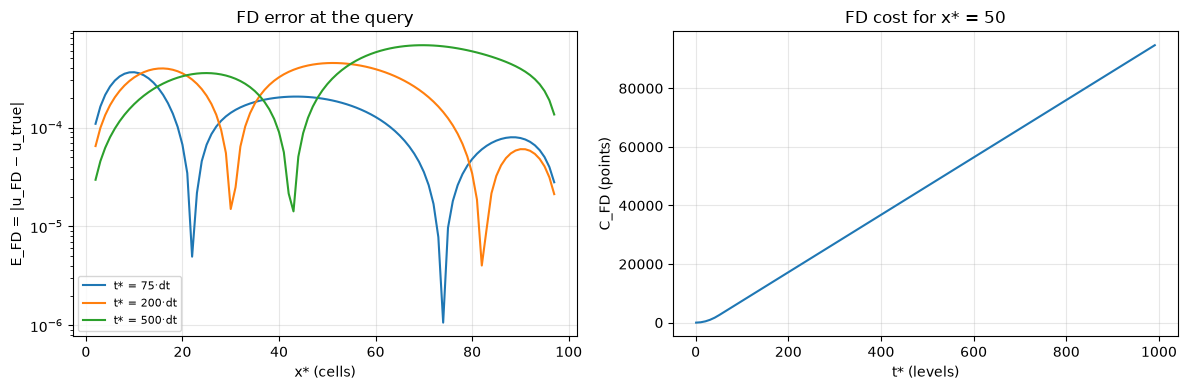

In [152]:
# ── FD reference: the tight central stencil (k=1, W=1, s=0) at every point ──
r, nu = alpha * dt / dx**2, c * dt / dx
W_FD = np.array([r + nu / 2, 1 - 2 * r, r - nu / 2])      # weights for (x-dx, x, x+dx)
print(f"FD weights = {np.round(W_FD, 6)},  sum = {W_FD.sum():.6f},  all positive: {bool((W_FD > 0).all())}")

_fd_cache = {}

def fd_reference(ix, it):
    """FD at z* = (ix, it): (u_fd, E_FD, C_FD). Cached in a dict so the env can be sent to subprocesses."""
    if (ix, it) in _fd_cache:
        return _fd_cache[(ix, it)]
    u = u_true(np.arange(nx) * dx, 0.0)                    # level 0: initial condition
    for _ in range(it):
        u[1:-1] = W_FD[0] * u[:-2] + W_FD[1] * u[1:-1] + W_FD[2] * u[2:]
        u[0] = u[-1] = 0.0                                   # boundaries
    u_fd = u[ix]
    E_FD = abs(u_fd - u_true(ix * dx, it * dt)[0])
    C_FD = sum(min(nx - 2, ix + j) - max(1, ix - j) + 1 for j in range(it))
    _fd_cache[(ix, it)] = (u_fd, E_FD, C_FD)
    return _fd_cache[(ix, it)]

# ── Table for a few queries ──
print(f"\n{'x*':>4} {'t*':>5} | {'u_FD':>9} {'u_true':>9} {'E_FD':>9} {'C_FD':>7}")
for ix, it in [(50, 10), (50, 75), (50, 200), (25, 200), (75, 200), (50, 500)]:
    u_fd, E, C = fd_reference(ix, it)
    print(f"{ix:>4} {it:>5} | {u_fd:9.6f} {u_true(ix * dx, it * dt)[0]:9.6f} {E:9.2e} {C:>7d}")

# ── Picture: FD error across x* (does it dip by luck?) and FD cost vs t* ──
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ixs = np.arange(2, nx - 2)
for it in [75, 200, 500]:
    a1.semilogy(ixs, [fd_reference(i, it)[1] for i in ixs], label=f"t* = {it}·dt")
a1.set(xlabel="x* (cells)", ylabel="E_FD = |u_FD − u_true|", title="FD error at the query")
a1.legend(fontsize=8); a1.grid(alpha=0.3)

its = np.arange(1, 1001, 10)
a2.plot(its, [fd_reference(50, i)[2] for i in its])
a2.set(xlabel="t* (levels)", ylabel="C_FD (points)", title="FD cost for x* = 50")
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Possible Actions


# Solve Weights


In [153]:
N_NB     = 3        # neighbours per point
K_T      = 2        # |dt| <= 2  levels (up or down)
R_X      = 2        # |dx| <= 2 cells  (left or right)
H_TOP    = 2        # ceiling: no point above t* + H_TOP
COND_MAX = 1e4      # reject nearly rank-deficient systems

# every cell a neighbour can be picked from, relative to the point (the point itself excluded)
WINDOW  = [(dix, dit) for dit in range(-K_T, K_T + 1) for dix in range(-R_X, R_X + 1)
           if (dix, dit) != (0, 0)]
N_CELLS = len(WINDOW)

COND_MAX = 1e4
W_MAX    = 1.5      # cap on ||w||_1, the per-level error-amplification factor (thesis Thm 2.7)

def solve_weights(dxs, dts, w_max=W_MAX):
    """Min-norm weights (pseudo-inverse) for the 3 PDE-substituted Taylor rows.
    None if rank-deficient, ill-conditioned, or ||w||_1 > w_max."""
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones_like(dxs),
                  (dxs - c * dts) / h,
                  (0.5 * dxs**2 + alpha * dts) / h**2])
    if np.linalg.matrix_rank(A) < 3 or np.linalg.cond(A) > COND_MAX:
        return None
    w = np.linalg.pinv(A) @ np.array([1.0, 0.0, 0.0])
    return w if np.abs(w).sum() <= w_max * (1 + 1e-9) else None


# Neighbours?

In [154]:
## First two functions, they are used to list the cells and say what is allowed and what is not for the next pick

def place(ix, it, a):
    """Grid point of window cell a seen from (ix, it). Past a wall or below t = 0 -> moved onto it."""
    dix, dit = WINDOW[a]
    return (min(max(ix + dix, 0), nx - 1), max(it + dit, 0))

def candidates(ix, it, t_top):
    """Window cells that can be picked at (ix, it): below the ceiling, one cell per distinct point."""
    out, used = [], set()
    for a in range(N_CELLS):
        q = place(ix, it, a)
        if q[1] <= t_top and q not in used:
            used.add(q)
            out.append(a)
    return out

#checks if we can have rank 3 for the Taylor rows, meaning that the points of these cells can satisfy the Taylor expansion

def taylor_rank(ix, it, cells):
    """Rank of the 3 Taylor rows for the points of these cells (3 = the rows can be satisfied)."""
    pts = np.array([place(ix, it, a) for a in cells])
    dxs, dts = (pts[:, 0] - ix) * dx, (pts[:, 1] - it) * dt
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones_like(dxs), (dxs - c * dts) / h, (0.5 * dxs**2 + alpha * dts) / h**2])
    return np.linalg.matrix_rank(A)

_weights_cache = {}

def stencil_weights(ix, it, cells):
    """Min-norm weights for the chosen cells at (ix, it). Weights follow sorted(cells). None if unusable."""
    key = tuple((q[0] - ix, q[1] - it) for q in (place(ix, it, a) for a in sorted(cells)))
    if key not in _weights_cache:
        dxs = np.array([k[0] for k in key]) * dx
        dts = np.array([k[1] for k in key]) * dt
        _weights_cache[key] = solve_weights(dxs, dts)
    return _weights_cache[key]

def valid_sets(ix, it, sets):
    pts = np.array([place(ix, it, a) for a in range(N_CELLS)])
    dxs, dts = (pts[sets, 0] - ix) * dx, (pts[sets, 1] - it) * dt
    h = np.maximum(np.abs(dxs).max(1), np.sqrt(alpha * np.abs(dts).max(1)))[:, None]
    A = np.stack([np.ones_like(dxs), (dxs - c * dts) / h, (0.5 * dxs**2 + alpha * dts) / h**2], axis=1)
    lam = np.linalg.eigvalsh(A @ A.transpose(0, 2, 1))
    ok = lam[:, -1] <= COND_MAX**2 * lam[:, 0]
    w = np.linalg.pinv(A)[:, :, 0]                  # min-norm weights, same as solve_weights
    return ok & (np.abs(w).sum(1) <= W_MAX)

def pick_mask(ix, it, picks, t_top):
    """Which window cells may be picked next, given the picks so far (any order)."""
    cand = [a for a in candidates(ix, it, t_top) if a not in picks]          # rule 1: no repeats
    left = N_NB - len(picks)                                                 # picks still to make, this one included
    mask = np.zeros(N_CELLS, dtype=bool)
    before = np.array(picks, dtype=int)
    if left == 1:                                  # last pick: the 5 must give usable weights
        sets = np.array([[*picks, a] for a in cand])
        mask[cand] = valid_sets(ix, it, sets)
    elif left == 2:                                # 4th pick: some 5th pick must then work
        pairs = np.array([(a, b) for i, a in enumerate(cand) for b in cand[i + 1:]])
        ok = valid_sets(ix, it, np.hstack([np.tile(before, (len(pairs), 1)), pairs]))
        mask[pairs[ok].ravel()] = True
    elif len(cand) >= left and taylor_rank(ix, it, picks + cand) == 3:
        mask[cand] = True                          # early picks: a full-rank finish is still reachable
    return mask

# checks
t_top = 75 + H_TOP
print("cells at (50, 75), first pick:", pick_mask(50, 75, [], t_top).sum())
print("cells at (50, 79), at the ceiling:", pick_mask(50, 79, [], t_top).sum())
print("cells at (1, 1), wall + IC corner:", pick_mask(1, 1, [], t_top).sum())
row = [WINDOW.index((d, -1)) for d in (-2, -1, 0, 1, 2)]
print("5 in a row one level down:", np.round(stencil_weights(50, 75, row), 4))
print("same 5, other order:      ", np.round(stencil_weights(50, 75, row[::-1]), 4))

cells at (50, 75), first pick: 24
cells at (50, 79), at the ceiling: 5
cells at (1, 1), wall + IC corner: 15
5 in a row one level down: [0.0519 0.2831 0.3571 0.274  0.0338]
same 5, other order:       [0.0519 0.2831 0.3571 0.274  0.0338]


In [155]:
_mask_cache = {}

def situation(ix, it, t_top):
    """What the window 'sees' at (ix, it): distances to the walls, the IC and the ceiling, capped at the window size.
    Two points with the same situation have exactly the same masks and weights."""
    return (min(ix, R_X), min(nx - 1 - ix, R_X), min(it, K_T), min(t_top - it, K_T))

def pick_mask_fast(ix, it, picks, t_top):
    """Same result as pick_mask, computed once per (situation, set of picks) and then looked up."""
    key = (situation(ix, it, t_top), tuple(sorted(picks)))
    if key not in _mask_cache:
        _mask_cache[key] = pick_mask(ix, it, picks, t_top)
    return _mask_cache[key]

In [156]:

def is_known(ix, it):
    """Initial condition or boundary: the value is free."""
    return it == 0 or ix == 0 or ix == nx - 1

def start_map(ix, it):
    """Empty map for the query z* = (ix, it)."""
    pending = [(-it, ix)]      # points waiting for their 5 neighbours
    seen    = {(ix, it)}       # every computed point created so far
    stencil = {}               # point -> (its 5 neighbour points, their weights)
    return pending, seen, stencil

def build_step(pending, seen, stencil, cells):
    """Pop the next point, give it the 5 picked cells, add new neighbours. Returns (point, n_new)."""
    neg_it, ix = heapq.heappop(pending)
    p = (ix, -neg_it)
    nbs = [place(*p, a) for a in sorted(cells)]      # same order as the weights
    stencil[p] = (nbs, stencil_weights(*p, cells))
    n_new = 0
    for q in nbs:
        if not is_known(*q) and q not in seen:
            seen.add(q)
            heapq.heappush(pending, (-q[1], q[0]))
            n_new += 1
    return p, n_new


In [157]:
import warnings
from scipy.sparse import coo_matrix, identity
from scipy.sparse.linalg import spsolve

U0 = u_true(np.arange(nx) * dx, 0.0)          # initial condition on the grid

def known_value(ix, it):
    """Value of a known point: the IC at t = 0, zero on the walls."""
    return U0[ix] if it == 0 else 0.0

def evaluate(stencil):
    """Pass 3: solve (I - W) u_hat = b for every computed point at once. None if it can't be solved."""
    pts = list(stencil)
    idx = {p: i for i, p in enumerate(pts)}
    rows, cols, vals, b = [], [], [], np.zeros(len(pts))
    for p, (nbs, w) in stencil.items():
        for q, wq in zip(nbs, w):
            if is_known(q[0], q[1]):
                b[idx[p]] += wq * known_value(q[0], q[1])      # known neighbour -> right-hand side
            else:
                rows.append(idx[p]); cols.append(idx[q]); vals.append(wq)   # computed neighbour -> W
    M = identity(len(pts), format="csc") - coo_matrix((vals, (rows, cols)), shape=(len(pts), len(pts))).tocsc()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                          # singular M -> NaNs, caught below
        u = spsolve(M, b)
    if not np.all(np.isfinite(u)) or np.abs(M @ u - b).max() > 1e-8:
        return None
    return dict(zip(pts, u))

# RL Environment

In [158]:
def new_cells(ix, it, seen):
    """For each window cell: 1 if its point would be a NEW computed point, 0 if known data or already created."""
    out = np.zeros(N_CELLS, dtype=np.float32)
    for a in range(N_CELLS):
        q = place(ix, it, a)
        out[a] = not is_known(*q) and q not in seen
    return out

class BackwardMapEnv(gym.Env):
    def __init__(self, queries, w_err=1.0, w_cost=1.0, e_tol=1e-4):
        super().__init__()
        self.queries = queries                     # list of z* = (ix, it), one sampled per episode
        self.w_err, self.w_cost, self.e_tol = w_err, w_cost, e_tol
        # obs = [x, t, pick number] + picked so far (80) + new point per cell (80)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(3 + 2 * N_CELLS,), dtype=np.float32)
        self.action_space = spaces.Discrete(N_CELLS)   # one action = one window cell

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.z_star = self.queries[self.np_random.integers(len(self.queries))]
        self.t_top  = min(self.z_star[1] + H_TOP, nt - 1)     # ceiling for this episode
        self.pending, self.seen, self.stencil = start_map(*self.z_star)
        self.picks = []                                       # cells picked so far for the current point
        return self._obs(), {}

    def _current(self):
        """The next point to expand (latest t first), not popped yet."""
        neg_it, ix = self.pending[0]
        return ix, -neg_it

    def _obs(self):
        ix, it = self._current()
        picked = np.zeros(N_CELLS, dtype=np.float32)
        picked[self.picks] = 1
        return np.concatenate([[ix, it, len(self.picks)], picked, new_cells(ix, it, self.seen)]).astype(np.float32)


## Stepping step


In [159]:
def step(self, a):
    self.picks.append(int(a))
    if len(self.picks) < N_NB:                                 # still choosing this point's 5 neighbours
        return self._obs(), 0.0, False, False, {}

    build_step(self.pending, self.seen, self.stencil, self.picks)   # 5 picks made: add the stencil
    self.picks = []
    if self.pending:                                           # map not finished: no reward yet
        return self._obs(), 0.0, False, False, {}

    # map finished: solve for the values, then the terminal reward
    ix, it  = self.z_star
    u_hat   = evaluate(self.stencil)
    err     = 1.0 if u_hat is None else min(abs(u_hat[self.z_star] - u_true(ix * dx, it * dt)[0]), 1.0)
    N, C    = len(self.seen), fd_reference(ix, it)[2]
    r_acc   = -self.w_err * np.log10(max(err, 1e-3 * self.e_tol) / self.e_tol) / 3
    r_cost  = -self.w_cost * np.log10(N / C) / 3
    info    = {"error": float(err), "n_points": N, "r_acc": float(r_acc), "r_cost": float(r_cost),
               "solved": u_hat is not None}
    return np.zeros(self.observation_space.shape, np.float32), r_acc + r_cost, True, False, info

def action_masks(self):
    ix, it = self._current()
    return pick_mask_fast(ix, it, self.picks, self.t_top)

BackwardMapEnv.step = step
BackwardMapEnv.action_masks = action_masks

def play(env, choose):
    """Run one episode; choose(env) returns the next cell. Returns (reward, info, steps)."""
    obs, _ = env.reset(seed=0)
    done, steps = False, 0
    while not done:
        obs, reward, done, _, info = env.step(choose(env))
        steps += 1
    return reward, info, steps

env = BackwardMapEnv(queries=[(50, 10)])

## Plotting

In [160]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm, Normalize

def plot_map(model, x_star, t_star, e_tol=1e-4, save=True, episode=None, img_dir=".", label=None):    # ── deterministic rollout (one step = one pick) ──
    env = BackwardMapEnv(queries=[(x_star, t_star)], e_tol=e_tol)
    obs, _ = env.reset(seed=0)
    done = False
    while not done:
        a, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, reward, done, _, info = env.step(int(a))

    # ── values, errors, stencil lines ──
    u_hat = evaluate(env.stencil)
    pts   = np.array(list(env.stencil.keys()))
    if u_hat is not None:
        err = np.array([abs(u_hat[(ix, it)] - u_true(ix * dx, it * dt)[0]) for ix, it in pts])
    else:
        err = np.full(len(pts), np.nan)
    lines = [[p, q] for p, (nbs, w) in env.stencil.items() for q in nbs]
    line_dt = np.array([q[1] - p[1] for p, q in lines])            # < 0: neighbour below, > 0: above
    mean_dt = np.array([np.mean([q[1] - p[1] for q in env.stencil[tuple(p)][0]]) for p in pts])
    known = np.array(sorted({tuple(q) for p, q in lines if is_known(*q)}), dtype=int).reshape(-1, 2)
    
    u_ref = u_true(x_star * dx, t_star * dt)[0]
    dt_norm, err_norm = Normalize(-K_T, K_T), LogNorm(vmin=1e-7, vmax=1e-1)

    def draw(ax, size):
        ax.add_collection(LineCollection(lines, array=line_dt, cmap="coolwarm", norm=dt_norm, lw=0.8, alpha=0.6))
        ax.scatter(known[:, 0], known[:, 1], s=size, marker="s", color="orange", zorder=2, label="known data")
        sc = ax.scatter(pts[:, 0], pts[:, 1], s=size, c=np.maximum(err, 1e-16), cmap="viridis",
                        norm=err_norm, edgecolors="k", linewidths=0.3, zorder=3)
        ax.axhline(env.t_top, color="gray", ls="--", lw=1, label="ceiling")
        ax.plot(x_star, t_star, "r*", ms=18, mec="k", zorder=4, label="z*")
        ax.set(xlabel="x (cells)", ylabel="t (levels)")
        return sc

    fig, ((axL, axR), (axS, axE)) = plt.subplots(2, 2, figsize=(15, 11))

    # top-left: full map (points coloured by their error)
    sc = draw(axL, 12)
    axL.set(xlim=(-1, nx), ylim=(-2, env.t_top + 2), title=f"Map: {len(pts)} computed points")
    axL.legend(loc="upper left", fontsize=8)
    fig.colorbar(sc, ax=axL, label="|u_hat − u_true| at each point")

    # top-right: zoom near z* (lines coloured by the neighbour's dt)
    draw(axR, 60)
    axR.set(xlim=(x_star - 15, x_star + 15), ylim=(max(-1, t_star - 20), env.t_top + 1), title="Zoom near z*")
    fig.colorbar(axR.collections[0], ax=axR, label="neighbour dt (blue = below, red = above)")

    # bottom-left: solution at t*, predicted vs true
    xs = np.linspace(0, 1, 400)
    axS.plot(xs, u_true(xs, 0.0), ":", color="gray", label="initial condition")
    axS.plot(xs, u_true(xs, t_star * dt), "k-", lw=2, label="exact u(x, t*)")
    axS.plot(x_star * dx, u_ref, "o", ms=12, mfc="none", mec="k", mew=2, label="true value at z*")
    if u_hat is not None:
        u_pred = u_hat[(x_star, t_star)]
        axS.plot(x_star * dx, u_pred, "r*", ms=16, mec="k", label="predicted at z*")
        box = (f"predicted  u_hat(z*) = {u_pred:.6f}\ntrue       u(z*)     = {u_ref:.6f}\n"
               f"error                = {abs(u_pred - u_ref):.2e}")
    else:
        box = f"solve FAILED\ntrue  u(z*) = {u_ref:.6f}"
    axS.text(0.03, 0.05, box, transform=axS.transAxes, family="monospace", fontsize=10,
             bbox=dict(boxstyle="round", fc="lightyellow", ec="gray"))
    axS.set(xlabel="x", ylabel="u", title="Solution at t*")
    axS.legend(fontsize=8, loc="upper right")

    # bottom-right: error of every point vs t, coloured by its average neighbour dt
    sc = axE.scatter(pts[:, 1], np.maximum(err, 1e-16), s=12, c=mean_dt, cmap="coolwarm", norm=dt_norm)
    fig.colorbar(sc, ax=axE, label="average neighbour dt of the point")
    axE.axhline(e_tol, color="green", ls="--", label=f"e_tol = {e_tol:g}")
    axE.plot(t_star, max(info["error"], 1e-16), "r*", ms=16, mec="k", label="z*")
    axE.set(yscale="log", xlabel="t (levels)", ylabel="|u_hat − u_true|", title="Error of every computed point")
    axE.legend(fontsize=8)

    sup = (f"z* = ({x_star}, {t_star})  |  reward = {reward:.3f}  (accuracy {info['r_acc']:.3f}, "
           f"cost {info['r_cost']:.3f})  |  points = {info['n_points']}")
    if episode is not None:
        sup += f"  |  episode {episode:06d}"
    fig.suptitle(sup, fontsize=13)
    plt.tight_layout()

    if save:
        tag = label if label is not None else f"ep{episode:06d}"
        fig.savefig(os.path.join(img_dir, f"backward_t{t_star}dt_x{x_star}_{tag}.png"), dpi=120)
        plt.close(fig)
    else:
        plt.show()
    return info

In [161]:
class MetricsCallback(BaseCallback):
    """Counts finished episodes, logs error, points, r_acc, r_cost (mean of the last 100),
    and stops training after max_episodes."""
    def __init__(self, max_episodes):
        super().__init__()
        self.max_episodes = max_episodes
        self.hist = {"error": [], "n_points": [], "r_acc": [], "r_cost": []}

    def _on_step(self):
        for info in self.locals["infos"]:
            if "error" in info:                                    # only the last step of an episode has it
                for key in self.hist:
                    self.hist[key].append(info[key])
        for key, vals in self.hist.items():
            if vals:
                self.logger.record(f"rollout/mean_{key}", np.mean(vals[-100:]))
        self.logger.record("rollout/episodes", len(self.hist["error"]))
        return len(self.hist["error"]) < self.max_episodes         # False -> training stops

class SnapshotCallback(BaseCallback):
    """Every `every` finished episodes: save a plot_map figure and a model checkpoint."""
    def __init__(self, x_star, t_star, e_tol, img_dir, ckpt_dir, every=500):
        super().__init__()
        self.x_star, self.t_star, self.e_tol = x_star, t_star, e_tol
        self.img_dir, self.ckpt_dir, self.every = img_dir, ckpt_dir, every
        self.episodes = 0

    def _on_step(self):
        for info in self.locals["infos"]:
            if "error" in info:
                self.episodes += 1
                if self.episodes % self.every == 0:
                    plot_map(self.model, self.x_star, self.t_star, e_tol=self.e_tol,
                             save=True, episode=self.episodes, img_dir=self.img_dir)
                    self.model.save(os.path.join(self.ckpt_dir, f"backward_ep{self.episodes:06d}"))
        return True

def make_env(queries, e_tol):
    def _init():
        env = BackwardMapEnv(queries=queries, e_tol=e_tol)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [ ]:
x_star, t_star  = 50, 20
queries         = [(x_star, t_star)]         # z* sampled per episode (one for now)
e_tol           = 1e-4
seeds           = [6]

n_envs          = 12
n_steps         = 2048
batch_size      = 1024
max_episodes    = 1_000_000                     # training length, in episodes
snapshot_every  = 50                        # figure + checkpoint every N episodes

# ── Run directory ──
day, month = date.today().day, date.today().month
run_name   = f"t{t_star}_x{x_star}_etol{e_tol}"
run_dir    = os.path.join(f"runs_backward_{month}-{day}", run_name)
print("Run:", run_dir)

for seed in seeds:
    seed_dir = os.path.join(run_dir, f"seed{seed}")
    img_dir  = os.path.join(seed_dir, "images")
    ckpt_dir = os.path.join(seed_dir, "checkpoints")
    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"\n{'#' * 50}\nSEED {seed}\n{'#' * 50}")

    vec_env = SubprocVecEnv([make_env(queries, e_tol) for _ in range(n_envs)])

    model = MaskablePPO("MlpPolicy", vec_env, gamma=1.0, n_steps=n_steps, batch_size=batch_size,
                        learning_rate=2e-4, clip_range=0.1, ent_coef=0.01, seed=seed, verbose=1,
                        tensorboard_log=os.path.join(seed_dir, "logs"), device="cpu")

    model.learn(total_timesteps=10**12,                        # no step limit: max_episodes decides
                tb_log_name=f"seed{seed}", log_interval=2,
                callback=[MetricsCallback(max_episodes),
                          SnapshotCallback(x_star, t_star, e_tol, img_dir, ckpt_dir, every=snapshot_every)])

    model.save(os.path.join(ckpt_dir, "backward_final"))
    plot_map(model, x_star, t_star, e_tol=e_tol, save=True, img_dir=img_dir, label="final")
    vec_env.close()

Run: runs_backward_9-23\t20_x50_etol0.0001

##################################################
SEED 6
##################################################
Using cpu device
Logging to runs_backward_9-23\t20_x50_etol0.0001\seed6\logs\seed6_1
------------------------------------------
| rollout/                |              |
|    episodes             | 0            |
| time/                   |              |
|    fps                  | 7002         |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 49152        |
| train/                  |              |
|    approx_kl            | 0.0024502377 |
|    clip_fraction        | 0.076        |
|    clip_range           | 0.1          |
|    entropy_loss         | -2.56        |
|    explained_variance   | 0.412        |
|    learning_rate        | 0.0002       |
|    loss                 | -0.0138      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.

Exception ignored in: <_io.BytesIO object at 0x0000021DB3C28FE0>
Traceback (most recent call last):
  File "c:\Users\amt35\OneDrive\RL For PDEs\Taylor linear predictor\venv\Lib\site-packages\matplotlib\_api\__init__.py", line 226, in check_in_list
    if not exists:
BufferError: Existing exports of data: object cannot be re-sized


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 6.1e+03      |
|    ep_rew_mean          | -0.563       |
|    episodes             | 204          |
|    mean_error           | 0.0103       |
|    mean_n_points        | 2.03e+03     |
|    mean_r_acc           | -0.328       |
|    mean_r_cost          | -0.235       |
| time/                   |              |
|    fps                  | 6432         |
|    iterations           | 52           |
|    time_elapsed         | 198          |
|    total_timesteps      | 1277952      |
| train/                  |              |
|    approx_kl            | 0.0015094182 |
|    clip_fraction        | 0.0418       |
|    clip_range           | 0.1          |
|    entropy_loss         | -2.39        |
|    explained_variance   | 0.842        |
|    learning_rate        | 0.0002       |
|    loss                 | -0.0251      |
|    n_updates            | 510          |
|    policy

In [ ]:
# ── Resume training from the last checkpoint for extra_episodes more episodes ──
x_star, t_star  = 50, 20
e_tol           = 1e-4
seed            = 4
extra_episodes  = 10_000          # <- how many MORE episodes to run
snapshot_every  = 50

run_dir  = "runs_backward_9-22/t20_x50_etol0.0001"
seed_dir = os.path.join(run_dir, f"seed{seed}")
ckpt_dir = os.path.join(seed_dir, "checkpoints")

img_dir_resumed = os.path.join(seed_dir, "images_resumed")   # separate from the original images/
os.makedirs(img_dir_resumed, exist_ok=True)

resume_from = os.path.join(ckpt_dir, "backward_final.zip")
queries     = [(x_star, t_star)]
n_envs      = 12

vec_env = SubprocVecEnv([make_env(queries, e_tol) for _ in range(n_envs)])
model   = MaskablePPO.load(resume_from, env=vec_env, device="cpu")

model.learn(total_timesteps=10**12,
            reset_num_timesteps=False,        # keeps the tensorboard x-axis continuous
            tb_log_name=f"seed{seed}", log_interval=2,
            callback=[MetricsCallback(extra_episodes),
                      SnapshotCallback(x_star, t_star, e_tol, img_dir_resumed, ckpt_dir, every=snapshot_every)])

model.save(os.path.join(ckpt_dir, "backward_final_resumed"))
plot_map(model, x_star, t_star, e_tol=e_tol, save=True, img_dir=img_dir_resumed, label="final_resumed")
vec_env.close()

Logging to runs_backward_9-22\t20_x50_etol0.0001\seed4\logs\seed4_1
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 5.94e+03     |
|    ep_rew_mean          | -1.56        |
|    episodes             | 0            |
| time/                   |              |
|    fps                  | 8139         |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 42942828     |
| train/                  |              |
|    approx_kl            | 0.0016593946 |
|    clip_fraction        | 0.0642       |
|    clip_range           | 0.1          |
|    entropy_loss         | -2.58        |
|    explained_variance   | 0.935        |
|    learning_rate        | 0.0002       |
|    loss                 | -0.0309      |
|    n_updates            | 17460        |
|    policy_gradient_loss | -0.00284     |
|    value_loss           | 3.8e-05      |
-----------------------------